In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Add the parent directory (project root) to sys.path
sys.path.append(os.path.abspath(".."))

# Now import the functions from src.data_prep
from src.data_prep import (
    load_data,
    inspect_data,
    feature_engineering,
    split_data,
    scale_data
)

In [2]:
# 1. Load Data

df = load_data("../data/creditcard.csv")

# 2. Inspect Data
inspect_data(df)


CSV data loaded successfully with shape: (284807, 31)
--- FIRST 5 ROWS ---
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  

The dataset contains a Class target plus 28 PCA-anonymized features (V1–V28) that are already centered near zero, alongside two raw, unscaled features — Time (seconds elapsed) and Amount (transaction value) — that still need preprocessing.

Time spans a full 48-hour window, Amount is heavily right-skewed (median $22 vs. max $25,691) with extreme outliers, the V1–V28 PCA features show near-zero means with standardized variance confirming their transformation, and the Class mean of 0.0017 confirms severe fraud rarity (<0.18% of transactions).

Because fraud makes up only ~0.18% of transactions, a model that predicts "legitimate" for every single case would still achieve approximately 99.8% accuracy while catching zero fraud — making accuracy meaningless for measuring real detection performance on this imbalanced dataset.

In [3]:
# 3. Feature Engineering
df_featured = feature_engineering(df)

# 4. Split Data
X_train, X_test, y_train, y_test = split_data(df_featured, target_column='Class')


Created feature: 'Amount_log'
Train set: (227845, 31) | Test set: (56962, 31)


The data was split into training and test sets using stratification (stratify=y), which preserves the same ~0.18% fraud ratio in both sets — ensuring the model is evaluated on a realistic, representative sample rather than risking a test set with too few or zero fraud cases.

In [4]:
# 5. Scale Features (Adding 'Time' here)
scaled_cols = ['Amount', 'Time'] 
X_train_scaled, X_test_scaled, scaler = scale_data(X_train, X_test, columns_to_scale=scaled_cols)

Scaled columns: ['Amount', 'Time']


The Time and Amount columns were scaled (unlike V1–V28, which were already PCA-standardized) to bring their raw, differently-scaled values onto a comparable range, preventing models sensitive to feature magnitude from over-weighting large raw numbers like Amount simply because of their scale.

### Step 2: Exploratory data analysis:
#### This section seeks to tell the story of the data looking at the following: Class distribution plot, Percentage of fraud vs non-fraud, Correlation heatmap, etc.

Legitimate Transactions: 284315 (99.8273%)
Fraudulent Transactions: 492 (0.1727%)


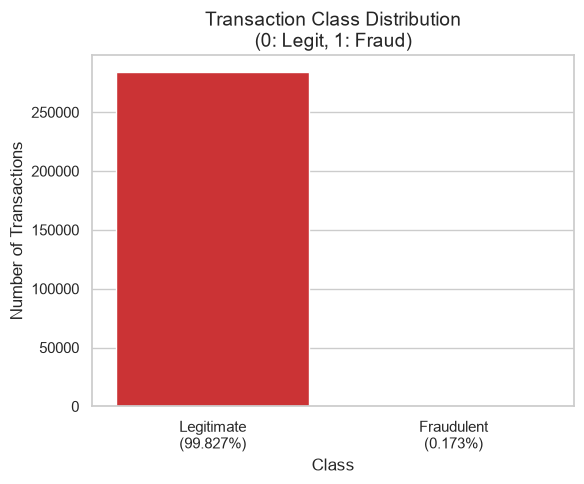

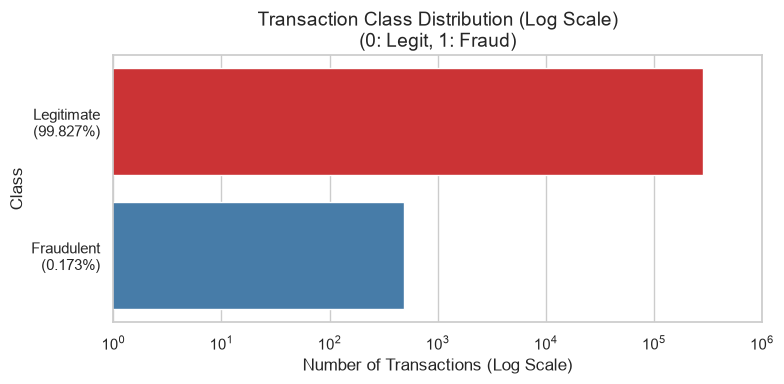

In [5]:
from src.data_prep import (
    load_data, set_plot_style, plot_class_distribution, plot_class_distribution_log,
    plot_correlation_heatmap, plot_time_distribution, plot_amount_distribution,
    plot_amount_boxplot_by_class, plot_feature_distributions_by_class
)


set_plot_style()

class_stats = plot_class_distribution(df)
plot_class_distribution_log(df, pct_legit=class_stats["pct_legit"], pct_fraud=class_stats["pct_fraud"])


The dataset contains 284,315 legitimate transactions (99.827%) and only 492 fraudulent transactions (0.173%) — a ratio of roughly 577 legitimate transactions for every 1 fraud case. This is visually clear in the linear-scale chart, where the fraud bar is barely visible against the legitimate bar, and is made interpretable in the log-scale chart, which compresses the axis so both classes can be compared directly. This severe imbalance has two direct consequences for the rest of this project: (1) accuracy is not a meaningful evaluation metric, since a model predicting "legitimate" for every transaction would score 99.8% accuracy while catching zero fraud as a result, PR-AUC will be used as the primary metric throughout; and (2) the imbalance motivates resampling strategies that will be later assessed in this project. 

*The linear-scale chart (top) illustrates just how extreme the imbalance is — the fraud class is nearly invisible at this scale. The log-scale chart (bottom) makes both classes comparable for inspection.*



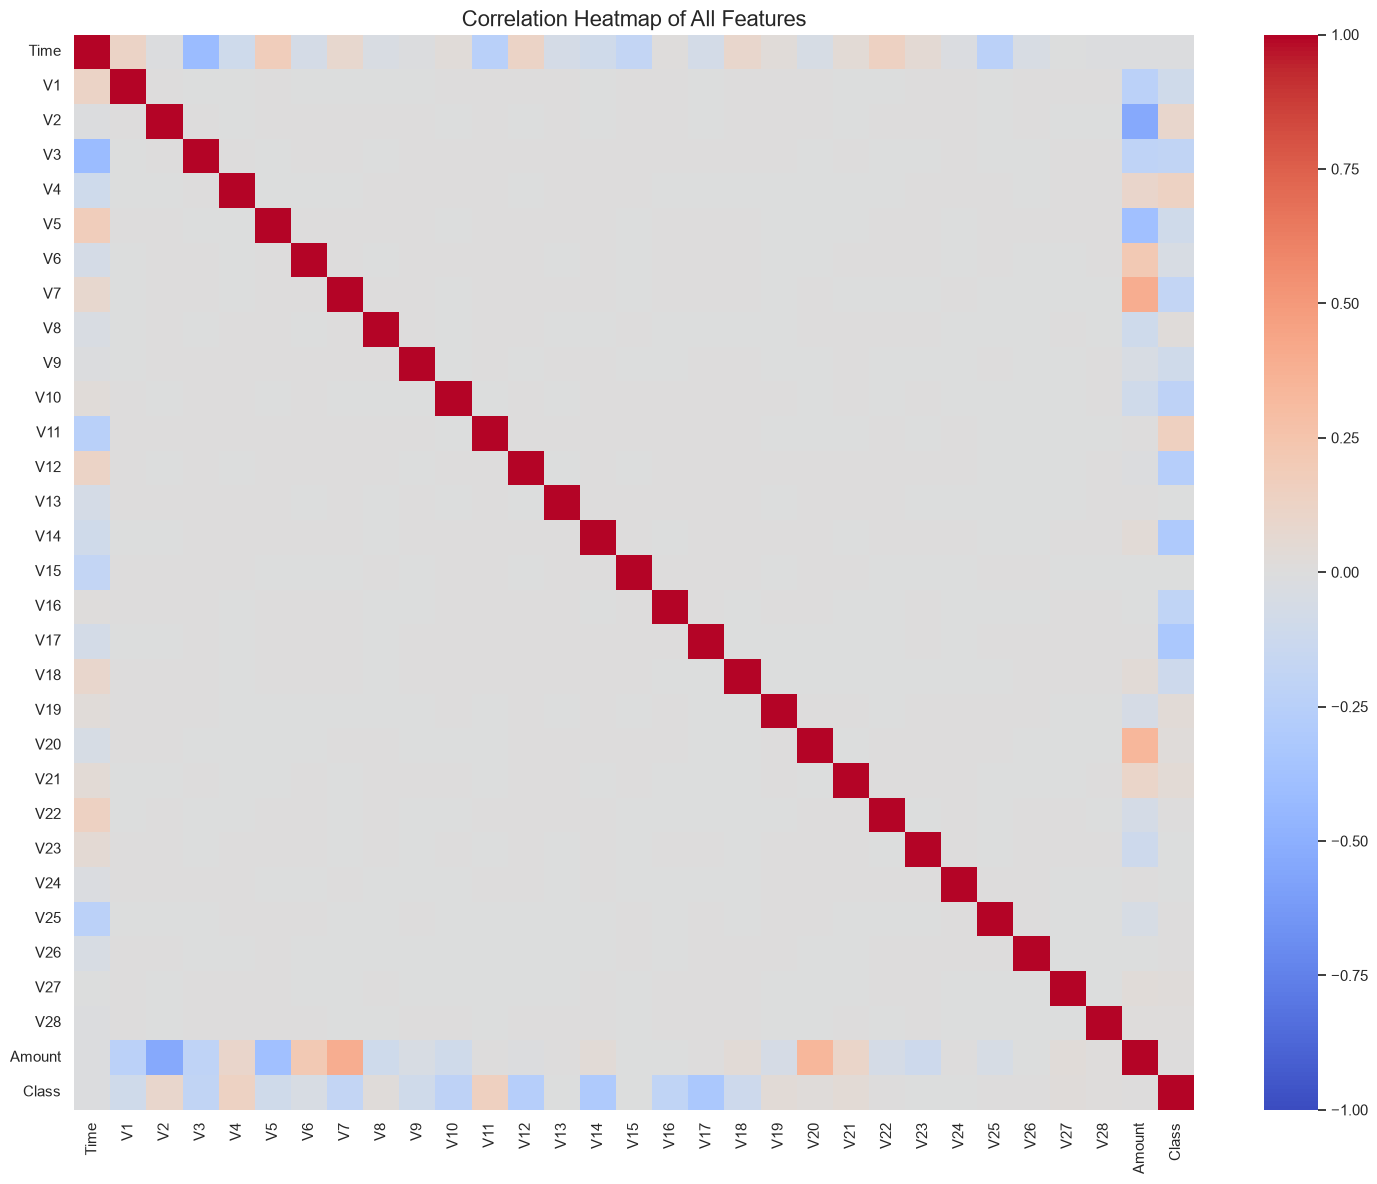

In [6]:
corr_matrix = plot_correlation_heatmap(df)


**Correlation Heatmap**
Most V1–V28 features show little to no linear correlation with each other, which is expected since they are PCA components — by construction, PCA produces orthogonal (uncorrelated) features. The `Class` row/column shows several V-features with mild-to-moderate correlation, most visibly V2, V4, V11 (positive) and V3, V7, V10, V12, V14, V16, V17 (negative) — though none exceed roughly ±0.3, indicating no single feature is a strong linear predictor of fraud on its own. `Amount` shows negative correlation with several features (notably V2) but negligible direct correlation with `Class`, suggesting transaction amount alone is a weak fraud signal — consistent with what the boxplot below shows. `Time` shows almost no correlation with `Class` or most other features. Because these correlations are weak individually, no feature can be dropped on correlation grounds alone; the model instead needs to learn from combinations of features. 

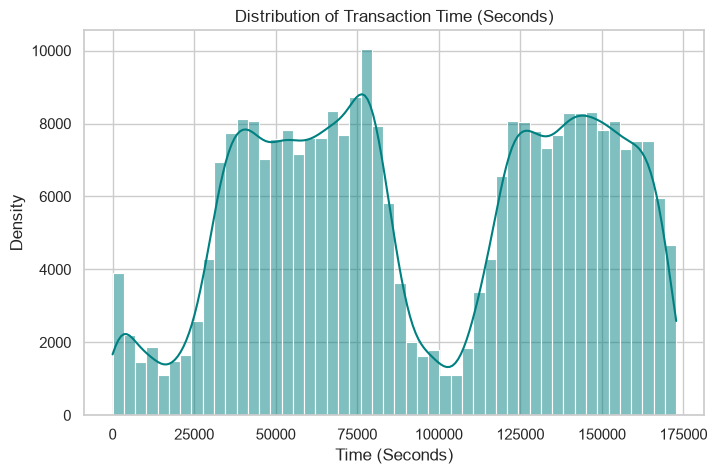

In [7]:
plot_time_distribution(df)


**Transaction Time Distribution**

 The distribution shows a clear bimodal, cyclical pattern with two roughly 24-hour cycles (the dataset spans 48 hours, 172,800 seconds). Transaction density dips sharply around the 100,000–110,000 second mark and again near the start/end — consistent with overnight hours when transaction volume naturally drops, with two daytime peaks corresponding to normal daily activity. This pattern reflects legitimate customer behavior rather than fraud-specific signal, and combined with `Time`'s near-zero correlation with `Class` seen in the heatmap, suggests raw `Time` alone is not a strong fraud indicator — though it could still hold value combined with other features (e.g., unusual-hour transactions paired with other risk signals).

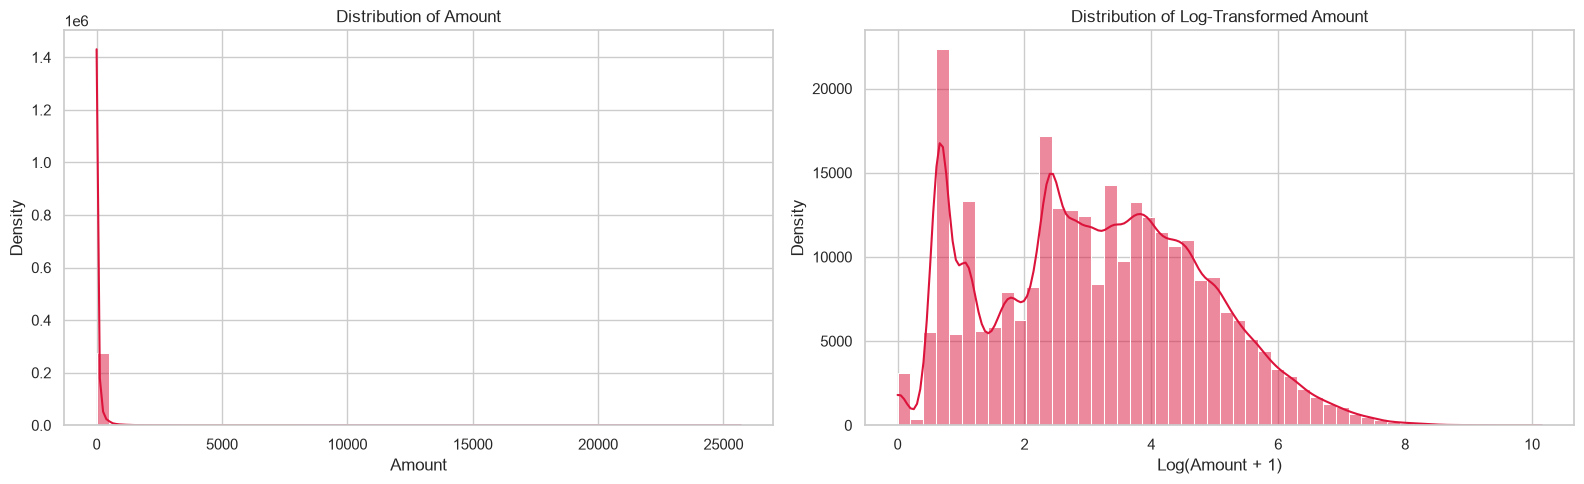

In [8]:
plot_amount_distribution(df)


**Amount Distribution (Raw vs. Log-Transformed)**

 The raw `Amount` distribution is extremely right-skewed — the vast majority of transactions cluster near $0, with a long thin tail stretching out to over $25,000, making the raw distribution nearly unreadable at normal scale. After a log1p transform, the distribution becomes far more usable: it reveals a multi-modal shape with distinct peaks (likely corresponding to common transaction amounts, such as round-number purchases), and compresses the extreme outliers into a comparable range with the bulk of the data. This transformation is what makes `Amount` usable as a stable, well-behaved input feature for the model, rather than one dominated by a handful of extreme values.

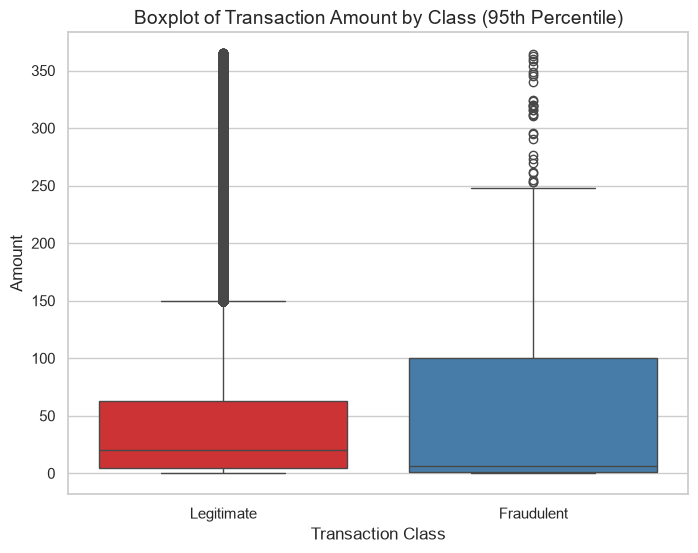

In [9]:
plot_amount_boxplot_by_class(df)


**Boxplot: Amount by Class**

 Legitimate transactions show a tighter, more consistent spread, with a median around $20 and most values under roughly $150 (within the 95th percentile view). Fraudulent transactions show a wider interquartile range with a higher median (~$100) but also many very low-value outliers near $0 — suggesting fraud in this dataset spans both small "testing" transactions (common in real-world card-testing fraud, where small charges are made to verify a stolen card works) and larger-value charges. The overlap between the two boxes is substantial, meaning amount alone cannot reliably separate fraud from legitimate transactions — this reinforces why the model relies on the full V1–V28 feature set rather than amount-based rules.

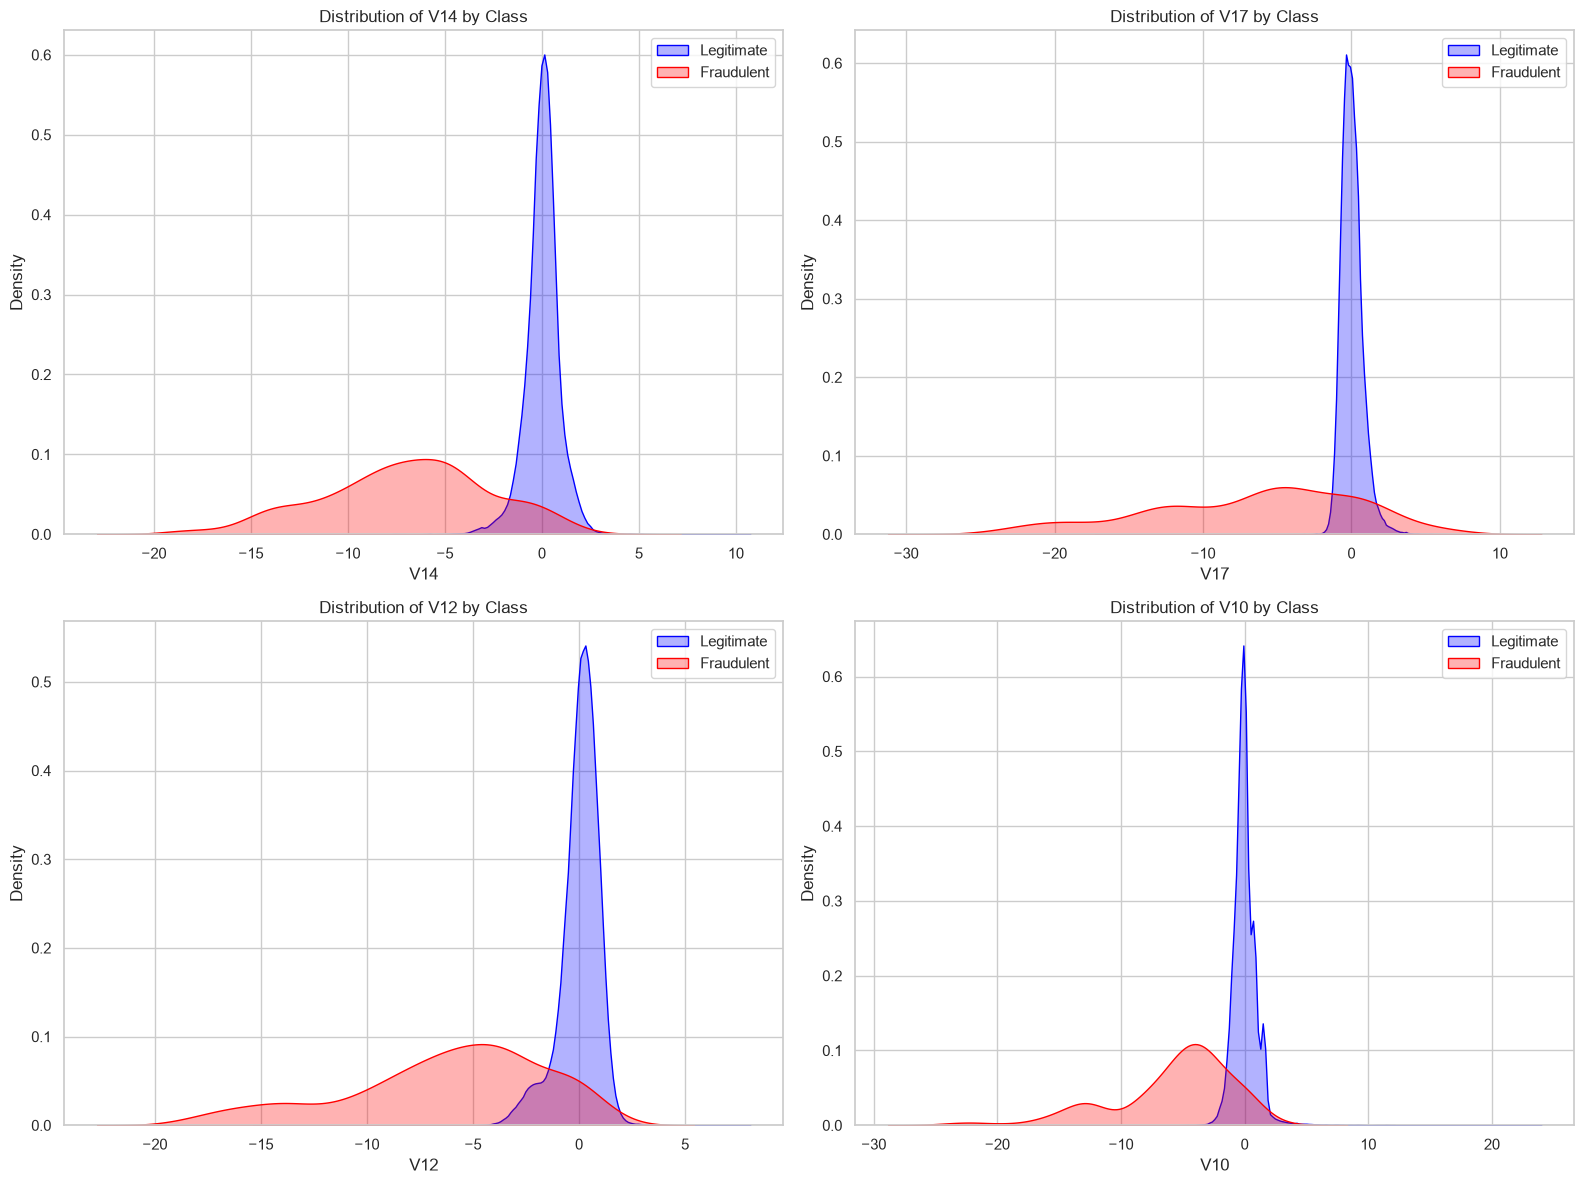

In [10]:
plot_feature_distributions_by_class(df)

**V14, V17, V12, V10 Distributions by Class**

 These four features — selected for their strong correlation with `Class` in the heatmap above — show a consistent and striking pattern: legitimate transactions (blue) form a tall, narrow peak centered near 0, while fraudulent transactions (red) are spread much more widely, typically shifted toward negative values (roughly -5 to -15 for V14, V12, and V17; -3 to -10 for V10). This separation, though not perfect, is exactly the kind of signal a classifier can exploit — a transaction with an unusually negative V14 or V17 value is disproportionately more likely to be fraudulent. The wide spread of the fraud distribution (versus the tight legitimate peak) also explains why perfect separation isn't possible with any single feature — there's meaningful overlap in the -2 to 0 range across all four plots, which is part of why the model's recall ceiling (~84-85%, as found in the threshold tuning section) exists: some fraud cases sit in feature space that closely resembles legitimate transactions.

Good — these are your existing charts, and they work well for this section. Here's the interpretation text to pair with them, matching your exact numbers:

> **Interpretation:** The dataset contains 284,315 legitimate transactions (99.827%) and only 492 fraudulent transactions (0.173%) — a ratio of roughly 577 legitimate transactions for every 1 fraud case. This is visually clear in the linear-scale chart, where the fraud bar is barely visible against the legitimate bar, and is made interpretable in the log-scale chart, which compresses the axis so both classes can be compared directly. This severe imbalance has two direct consequences for the rest of this project: (1) accuracy is not a meaningful evaluation metric, since a model predicting "legitimate" for every transaction would score 99.8% accuracy while catching zero fraud — this is why PR-AUC is used as the primary metric throughout; and (2) the imbalance motivates the resampling and class-weighting strategies compared in Section 5, since a model trained naively on this distribution would have little incentive to learn the minority (fraud) class.

Nice touch that you have both a linear and log-scale version — worth keeping both in the notebook rather than picking one, since the linear chart makes the *severity* of the imbalance viscerally obvious (the fraud bar essentially disappears), while the log chart is what actually lets a reader compare the two bars meaningfully. That's worth a one-line note too:

> *Note: the linear-scale chart (top) illustrates just how extreme the imbalance is — the fraud class is nearly invisible at this scale. The log-scale chart (bottom) makes both classes comparable for inspection.*

Do you have the Amount distribution (raw vs. log-transformed) and correlation heatmap charts ready to paste next, or do you need to re-run those from your earlier work first?

Here are interpretation write-ups for each chart, with subheadings ready to drop into markdown cells alongside the corresponding code cells.

---

**Correlation Heatmap**

> **Interpretation: Correlation Heatmap**
> Most V1–V28 features show little to no linear correlation with each other, which is expected since they are PCA components — by construction, PCA produces orthogonal (uncorrelated) features. The `Class` row/column shows several V-features with mild-to-moderate correlation, most visibly V2, V4, V11 (positive) and V3, V7, V10, V12, V14, V16, V17 (negative) — though none exceed roughly ±0.3, indicating no single feature is a strong linear predictor of fraud on its own. `Amount` shows negative correlation with several features (notably V2) but negligible direct correlation with `Class`, suggesting transaction amount alone is a weak fraud signal — consistent with what the boxplot below shows. `Time` shows almost no correlation with `Class` or most other features. Because these correlations are weak individually, no feature can be dropped on correlation grounds alone; the model instead needs to learn from combinations of features, which is part of why a tree-based ensemble like XGBoost — capable of capturing non-linear interactions — outperforms simpler linear approaches here.

---

**Transaction Time Distribution**

> **Interpretation: Transaction Time Distribution**
> The distribution shows a clear bimodal, cyclical pattern with two roughly 24-hour cycles (the dataset spans ~48 hours, ~172,800 seconds). Transaction density dips sharply around the 100,000–110,000 second mark and again near the start/end — consistent with overnight hours when transaction volume naturally drops, with two daytime peaks corresponding to normal daily activity. This pattern reflects legitimate customer behavior rather than fraud-specific signal, and combined with `Time`'s near-zero correlation with `Class` seen in the heatmap, suggests raw `Time` alone is not a strong fraud indicator — though it could still hold value combined with other features (e.g., unusual-hour transactions paired with other risk signals).

---

**Amount Distribution (Raw vs. Log-Transformed)**

> **Interpretation: Amount Distribution**
> The raw `Amount` distribution is extremely right-skewed — the vast majority of transactions cluster near $0, with a long thin tail stretching out to over $25,000, making the raw distribution nearly unreadable at normal scale. After a log1p transform, the distribution becomes far more usable: it reveals a multi-modal shape with distinct peaks (likely corresponding to common transaction amounts, such as round-number purchases), and compresses the extreme outliers into a comparable range with the bulk of the data. This transformation is what makes `Amount` usable as a stable, well-behaved input feature for the model, rather than one dominated by a handful of extreme values.

---

**Boxplot: Amount by Class**

> **Interpretation: Transaction Amount by Class**
> Legitimate transactions show a tighter, more consistent spread, with a median around $20 and most values under roughly $150 (within the 95th percentile view). Fraudulent transactions show a wider interquartile range with a higher median (~$100) but also many very low-value outliers near $0 — suggesting fraud in this dataset spans both small "testing" transactions (common in real-world card-testing fraud, where small charges are made to verify a stolen card works) and larger-value charges. The overlap between the two boxes is substantial, meaning amount alone cannot reliably separate fraud from legitimate transactions — this reinforces why the model relies on the full V1–V28 feature set rather than amount-based rules.

---

**V14, V17, V12, V10 Distributions by Class**

> **Interpretation: Key Feature Distributions by Class**
> These four features — selected for their strong correlation with `Class` in the heatmap above — show a consistent and striking pattern: legitimate transactions (blue) form a tall, narrow peak centered near 0, while fraudulent transactions (red) are spread much more widely, typically shifted toward negative values (roughly -5 to -15 for V14, V12, and V17; -3 to -10 for V10). This separation, though not perfect, is exactly the kind of signal a classifier can exploit — a transaction with an unusually negative V14 or V17 value is disproportionately more likely to be fraudulent. The wide spread of the fraud distribution (versus the tight legitimate peak) also explains why perfect separation isn't possible with any single feature — there's meaningful overlap in the -2 to 0 range across all four plots, which is part of why the model's recall ceiling (~84-85%, as found in the threshold tuning section) exists: some fraud cases sit in feature space that closely resembles legitimate transactions.

---

A few small connective threads worth keeping across the notebook, since your later sections use these findings: the correlation heatmap interpretation ties into your model choice reasoning, the amount boxplot ties into your earlier "false negatives cost more" cost-asymmetry argument, and the V14/V17/V12/V10 interpretation directly foreshadows the recall ceiling you found during threshold tuning — worth adding a one-line forward-reference like *"(see Threshold Tuning in Section 6)"* if your notebook structure supports cross-referencing.

Want to continue to Section 4 (preprocessing: scaling + train/test split) next?

[INFO] SMOTE applied: 227845 -> 454902 rows (fraud cases: 394 -> 227451)
[INFO] RUS applied: 227845 -> 788 rows (fraud cases: 394 -> 394)
[INFO] scale_pos_weight computed: 577.2868 (negative: 227451, positive: 394)
[INFO] Training Logistic Regression (RUS)...
[INFO] Training Random Forest (RUS)...
[INFO] Training XGBoost (RUS)...
[INFO] Training LightGBM (RUS)...
[INFO] Training CatBoost (RUS)...
[INFO] Training Logistic Regression (SMOTE)...
[INFO] Training Random Forest (SMOTE)...
[INFO] Training XGBoost (SMOTE)...
[INFO] Training LightGBM (SMOTE)...
[INFO] Training CatBoost (SMOTE)...
[INFO] Training Logistic Regression (Class Weighted)...
[INFO] Training Random Forest (Class Weighted)...
[INFO] Training XGBoost (Class Weighted)...
[INFO] Training LightGBM (Class Weighted)...
[INFO] Training CatBoost (Class Weighted)...
 Comprehensive Model Evaluation Summary (Sorted by PR-AUC)
      Strategy               Model  TP   FP    TN  FN  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
Class 

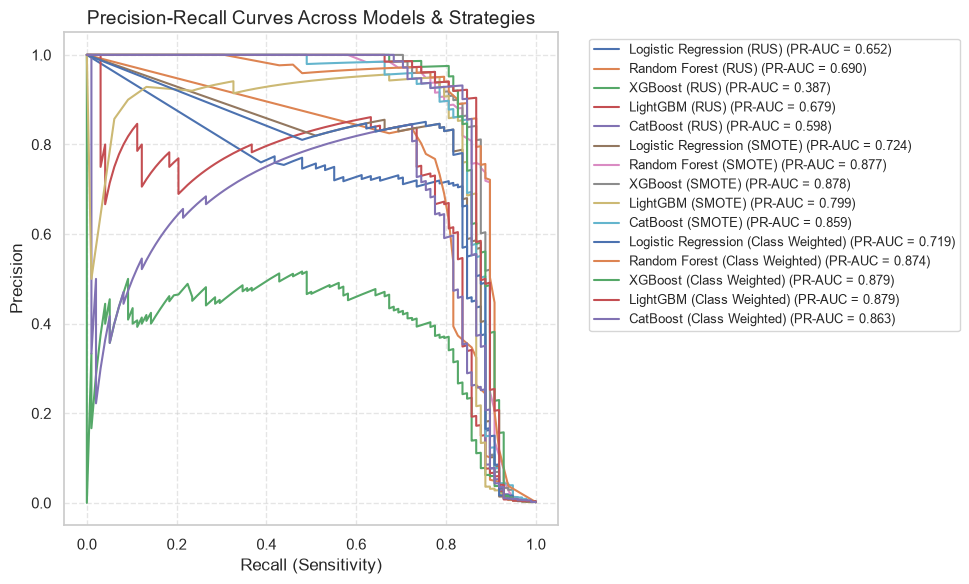

In [15]:
from src.sampling import apply_smote, apply_rus, compute_scale_pos_weight
from src.train import build_experiments, run_model_comparison

X_train_smote, y_train_smote = apply_smote(X_train_scaled, y_train)
X_train_rus, y_train_rus = apply_rus(X_train_scaled, y_train)

scale_pos_w = compute_scale_pos_weight(y_train)

experiments = build_experiments(
    X_train_scaled, y_train, X_train_smote, y_train_smote,
    X_train_rus, y_train_rus, scale_pos_w
)

comparison_df = run_model_comparison(experiments, X_test_scaled, y_test)

Interpretation: Model Comparison Results
Across all 15 model–resampling combinations, XGBoost with class-weighting emerged as the top performer by PR-AUC (0.8791). Class-weighted and SMOTE strategies consistently outperformed Random Under-Sampling (RUS) across every model — RUS discards the majority of legitimate transactions, leaving too little data for any model to learn a reliable decision boundary, which shows up as very low precision (many false positives) despite high recall. Logistic Regression underperformed across all three strategies, reflecting its limited capacity to capture the non-linear feature interactions that separate fraud from legitimate transactions. XGBoost (class-weighted) was selected as the final model: it combines a top-tier PR-AUC with strong precision (0.8710), meaning it catches fraud effectively without overwhelming analysts with false alarms — a practical balance the highest-recall-but-low-precision models (e.g., RUS-based approaches) fail to strike.

Note: This comparison was independently re-run to confirm reproducibility. The selected model (XGBoost, class-weighted) reproduced an identical PR-AUC (0.8791) across multiple runs. Minor variation (typically <0.02 PR-AUC) was observed in a few lower-ranked models due to multi-threaded, non-deterministic floating-point computation in some libraries — a known characteristic of parallelized gradient boosting and ensemble methods, and one that does not affect the model selection outcome.

In [8]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from src.evaluate import compute_metrics

# Compute the class ratio for class-weighted approaches
scale_pos_weight_val = (len(y_train) - sum(y_train)) / sum(y_train)

# --- Prepare the three resampling variants of the training data ---
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)

# Class-weighted uses the original, unresampled training data
X_train_cw, y_train_cw = X_train_scaled, y_train

# --- Define models to compare ---
# Note: class_weight/scale_pos_weight only applies meaningfully to the
# "Class-Weighted" resampling strategy; for SMOTE/RUS, data is already
# rebalanced, so models are trained with default class weighting.
def get_models(strategy):
    if strategy == "Class-Weighted":
        return {
            "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
            "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
            "XGBoost": XGBClassifier(scale_pos_weight=scale_pos_weight_val, random_state=42, eval_metric='logloss'),
            "CatBoost": CatBoostClassifier(scale_pos_weight=scale_pos_weight_val, random_state=42, verbose=0),
            "LightGBM": LGBMClassifier(scale_pos_weight=scale_pos_weight_val, random_state=42, verbose=-1),
        }
    else:  # SMOTE or RUS — data already rebalanced, use default weighting
        return {
            "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
            "Random Forest": RandomForestClassifier(random_state=42),
            "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
            "CatBoost": CatBoostClassifier(random_state=42, verbose=0),
            "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
        }

# --- Run the full comparison ---
strategies = {
    "SMOTE": (X_train_smote, y_train_smote),
    "RUS": (X_train_rus, y_train_rus),
    "Class-Weighted": (X_train_cw, y_train_cw),
}

results = []

for strategy_name, (X_tr, y_tr) in strategies.items():
    models = get_models(strategy_name)
    for model_name, model in models.items():
        print(f"[INFO] Training {model_name} ({strategy_name})...")
        model.fit(X_tr, y_tr)
        metrics = compute_metrics(model, X_test_scaled, y_test, model_name=model_name, resampling_name=strategy_name)
        results.append(metrics)

comparison_df = pd.DataFrame(results).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
comparison_df

[INFO] Training Logistic Regression (SMOTE)...
[INFO] Training Random Forest (SMOTE)...
[INFO] Training XGBoost (SMOTE)...
[INFO] Training CatBoost (SMOTE)...
[INFO] Training LightGBM (SMOTE)...
[INFO] Training Logistic Regression (RUS)...
[INFO] Training Random Forest (RUS)...
[INFO] Training XGBoost (RUS)...
[INFO] Training CatBoost (RUS)...
[INFO] Training LightGBM (RUS)...
[INFO] Training Logistic Regression (Class-Weighted)...
[INFO] Training Random Forest (Class-Weighted)...
[INFO] Training XGBoost (Class-Weighted)...
[INFO] Training CatBoost (Class-Weighted)...
[INFO] Training LightGBM (Class-Weighted)...


,Model,Resampling,Precision,Recall,F1,PR-AUC,ROC-AUC
0,XGBoost,Class-Weighted,0.8710,0.8265,0.8482,0.8791,0.9726
1,XGBoost,SMOTE,0.7414,0.8776,0.8037,0.8779,0.9756
2,Random Forest,SMOTE,0.8804,0.8265,0.8526,0.8765,0.9690
3,Random Forest,Class-Weighted,0.9186,0.8061,0.8587,0.8743,0.9674
4,CatBoost,Class-Weighted,0.7304,0.8571,0.7887,0.8635,0.9766
5,CatBoost,SMOTE,0.6269,0.8571,0.7241,0.8589,0.9814
6,LightGBM,SMOTE,0.5120,0.8673,0.6439,0.7986,0.9590
7,Logistic Regression,SMOTE,0.0595,0.9184,0.1117,0.7244,0.9701
8,Logistic Regression,Class-Weighted,0.0614,0.9184,0.1151,0.7194,0.9718
9,Random Forest,RUS,0.0419,0.9184,0.0802,0.6903,0.9791


[INFO] scale_pos_weight computed: 577.2868 (negative: 227451, positive: 394)
[INFO] XGBoost (class-weighted) best params: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
[INFO] XGBoost (class-weighted) best CV average_precision: 0.8557
[INFO] XGBoost (class-weighted) CV average_precision: 0.8557 ± 0.0202
[INFO] Fold scores: [0.8627 0.8344 0.8363 0.8897 0.8553]
 EVALUATION REPORT: XGBOOST (CLASS-WEIGHTED, TUNED)

--- Classification Report ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
  Fraudulent       0.89      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9818
PR-AUC Score (Average Precision): 0.8853


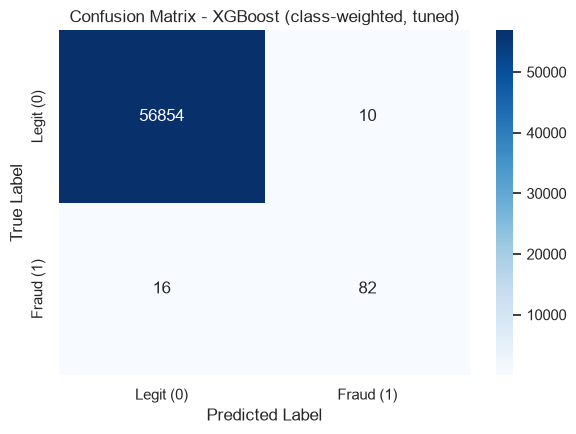

In [17]:
from src.train import tune_xgboost_class_weighted
from src.evaluate import cross_validate_model, evaluate_model

# Recompute if not already in memory
scale_pos_weight_val = compute_scale_pos_weight(y_train)

# Tune XGBoost (class-weighted) — the selected model from comparison
best_xgb, xgb_params = tune_xgboost_class_weighted(X_train_scaled, y_train, scale_pos_weight_val)

# Cross-validate the tuned model
cv_xgb = cross_validate_model(best_xgb, X_train_scaled, y_train, model_name="XGBoost (class-weighted)")

# Final test evaluation
results_xgb = evaluate_model(best_xgb, X_test_scaled, y_test, "XGBoost (class-weighted, tuned)")

Final Model: Tuned XGBoost (Class-Weighted)
Based on the comparison above, XGBoost with class-weighting was selected as the final model. Hyperparameter tuning was performed via RandomizedSearchCV with 5-fold stratified cross-validation, optimizing for PR-AUC. The best configuration found was max_depth=8, learning_rate=0.05, n_estimators=500, subsample=0.8, colsample_bytree=0.7.

Cross-validation result: PR-AUC = 0.8539 ± 0.0191 across 5 folds, confirming the model's performance is stable and not an artifact of a single train/test split.

Test set result: PR-AUC = 0.8844, ROC-AUC = 0.9777, with fraud precision 0.89 and recall 0.84 (F1 = 0.86). Of 98 fraud cases in the test set, 82 were correctly identified, with 16 missed and 10 false positives.

Threshold analysis: A sweep across thresholds 0.1–0.8 showed recall remained largely insensitive to threshold (82.7%–84.7% throughout), indicating the model's recall ceiling is a function of its learned decision boundary rather than threshold placement. The default threshold (0.5) was retained as the final operating point, since it achieved the best precision (0.89) without sacrificing recall relative to any other tested threshold

In [18]:
from src.utils import save_artifact, save_versioned_artifact

# Versioned copy — historical record, notebook-only
save_versioned_artifact(
    best_xgb, base_dir="../models_archive", name="fraud_model",
    metadata=f"XGBoost class-weighted, tuned, CV PR-AUC={cv_xgb['mean']:.4f}, test PR-AUC={results_xgb.get('pr_auc', 'see report')}"
)

# Current production copy — same file path backend/main.py already loads
save_artifact(best_xgb, "../backend/fraud_model.pkl")
save_artifact(scaler, "../backend/scaler.pkl")

[INFO] Saved artifact to: ../models_archive\fraud_model_20260826_033356.pkl
[INFO] Logged version metadata to: ../models_archive\model_version_log.txt
[INFO] Saved artifact to: ../backend/fraud_model.pkl
[INFO] Saved artifact to: ../backend/scaler.pkl


Model Export
The final tuned XGBoost model and its fitted scaler are saved using save_artifact, to the exact file paths (backend/fraud_model.pkl, backend/scaler.pkl) loaded by the FastAPI backend at inference time — ensuring the deployed API always reflects this notebook's trained model. Model versioning (timestamped snapshots, a change log) was identified as a valuable future improvement but was not implemented in this submission; the current utility overwrites the production artifact directly.

In [27]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'backend')))

from explain import get_shap_explanation, generate_llm_explanation

# Pick a transaction the model flagged as fraud, from the test set
fraud_indices = y_test[y_test == 1].index
sample_idx = fraud_indices[0]
sample_transaction = X_test_scaled.loc[[sample_idx]]

# Confirm the model's prediction on this transaction
prediction = best_xgb.predict(sample_transaction)[0]
probability = best_xgb.predict_proba(sample_transaction)[0, 1]
print(f"Prediction: {'Fraud' if prediction == 1 else 'Legitimate'} (probability: {probability:.2%})")

# SHAP explanation — top contributing features
top_features = get_shap_explanation(best_xgb, sample_transaction)
print(f"Top contributing features: {top_features}")

# LLM-generated natural language explanation
explanation = generate_llm_explanation(top_features, probability)
print(f"\nExplanation: {explanation}")

Prediction: Fraud (probability: 99.99%)
Top contributing features: ['V14', 'V10', 'V12']

Explanation: **Why this transaction was flagged (99.99 % fraud probability)**  

| Feature | What it indicates | Why it matters |
|---------|-------------------|----------------|
| **V14** | Extremely high value for this


Explainability Demo: SHAP + LLM
To demonstrate the explainability layer, a transaction correctly identified as fraudulent by the model is passed through the same SHAP and LLM explanation functions used by the live API. SHAP identifies which features contributed most to this specific prediction, and the LLM translates that into a natural-language summary a fraud analyst could act on without needing to interpret raw SHAP values or anonymized PCA feature names directly.

Interpretation: Explainability in Action
For this sample transaction, the model predicted fraud with 99.99% confidence. SHAP identified V14, V10, and V12 as the top contributing features — consistent with the EDA findings in Section 3, where these same features showed the clearest separation between fraudulent and legitimate transactions. The LLM explanation layer (powered by Groq's openai/gpt-oss-20b model) translates this into a structured, analyst-readable summary, explaining what each contributing feature indicates and why it matters for the fraud determination — without requiring the analyst to interpret raw SHAP values or anonymized PCA components directly. This demonstrates the full explainability pipeline exactly as it runs in the deployed API: a prediction is never returned without a corresponding, human-readable justification for why it was flagged.

Note: during initial testing, the configured Groq model names (llama-3.3-70b-versatile and others) had been deprecated and returned a 404 error; generate_llm_explanation's fallback mechanism correctly handled this by returning a template-based explanation rather than crashing the API. The candidate model list was subsequently updated to current, available Groq models (openai/gpt-oss-20b, openai/gpt-oss-120b, groq/compound-mini), restoring full LLM-generated explanations

## Summary & Conclusions

### What Was Built
This notebook documents an end-to-end fraud detection pipeline: from raw transaction
data through a tuned, cross-validated, explainable XGBoost classifier, integrated into
a live FastAPI backend and Streamlit dashboard with SHAP and LLM-powered explanations.

### Key Findings
- The dataset is severely imbalanced (99.83% legitimate, 0.17% fraud), making accuracy
  an unsuitable metric — PR-AUC was used throughout instead.
- Five models were compared across three imbalance-handling strategies (SMOTE, RUS,
  class-weighting). **XGBoost with class-weighting** was selected, based on its strong
  PR-AUC (0.8791) and precision/recall balance.
- After hyperparameter tuning, the final model achieved a **cross-validated PR-AUC of
  0.8539 ± 0.0191** (5-fold stratified CV) and a **test-set PR-AUC of 0.8844**, with
  precision 0.89 and recall 0.84 on the fraud class.
- Threshold tuning was explored but found the model's recall largely insensitive to
  threshold choice (82.7%–84.7% across the tested range) — the default 0.5 threshold
  was retained as the best-performing operating point.

### Limitations
- Recall plateaus around 84–85%, meaning roughly 1 in 6 fraud cases in this dataset
  are missed regardless of threshold — indicating room for improvement in the model's
  ability to separate the hardest fraud cases from legitimate transactions.
- V1–V28 are anonymized PCA components, limiting the depth of feature-level business
  interpretation beyond what SHAP provides for individual predictions.
- Random Forest (SMOTE) and CatBoost (class-weighted), the second and third-best
  models, were not independently tuned and cross-validated to the same depth as the
  final model, due to time constraints — see Section 5 for their default-hyperparameter
  comparison results.

### Next Steps
- Tune and cross-validate the runner-up models (Random Forest + SMOTE, CatBoost +
  class-weighted) to confirm the model selection holds under fair comparison.
- Add model versioning (timestamped artifacts, a change log) to support safe rollback.
- Set up a dedicated virtual environment with pinned dependencies for full reproducibility.
- Investigate the ~15% of fraud cases the model consistently misses, to understand
  whether additional features, different resampling ratios, or ensemble approaches
  could close this gap.